# Adversarial Attacks

The goal of an adversarial attack is to create an image by introducing a small perturbation in a legitimate image, correctly classified by a DL model, such that the perturbed image is misclassified. While many adversarial attacks aim for changes that are difficult for humans to notice, imperceptibility is not a strict requirement.

In this notebook, we present two methods to craft adversarial samples using deep learning networks: **Fast Gradient Sign Method (FGSM)**, and **Projected Gradient Descent (PGD).**

**FGSM paper:**

Explaining and Harnessing Adversarial Examples, Ian J. Goodfellow, Jonathon Shlens, Christian Szegedy - https://arxiv.org/abs/1412.6572

**PGD paper:**

Towards Deep Learning Models Resistant to Adversarial Attacks, Aleksander Madry, Aleksandar Makelov, Ludwig Schmidt - https://arxiv.org/pdf/1706.06083



## Preparation

In [224]:
import torch
import torchvision
from torchvision.transforms import v2

import torchinfo

import matplotlib.pyplot as plt
import numpy as np
import time

from PIL import Image

# importing a module with utilities for displaying stats and data
import sys
sys.path.insert(1, 'util')
import vcpi_util

### Model definition

In [225]:
class Conv(torch.nn.Module):

    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = torch.nn.Conv2d(3, 16, 3)
        self.bn1 = torch.nn.BatchNorm2d(16)
        self.relu1 = torch.nn.ReLU()

        self.conv2 = torch.nn.Conv2d(16, 32, 3)
        self.bn2 = torch.nn.BatchNorm2d(32)
        self.relu2 = torch.nn.ReLU()

        self.maxpool1 = torch.nn.MaxPool2d(2)


        self.conv3 = torch.nn.Conv2d(32, 48, 3)
        self.bn3 = torch.nn.BatchNorm2d(48)
        self.relu3 = torch.nn.ReLU()

        self.conv4 = torch.nn.Conv2d(48, 48, 3)
        self.bn4 = torch.nn.BatchNorm2d(48)
        self.relu4 = torch.nn.ReLU()

        self.maxpool2 = torch.nn.MaxPool2d(2)

        self.fc1 = torch.nn.Linear(1200, num_classes)
        

    def forward(self, x):    
        
        # input = (bs, 3, 32, 32)
        x = self.conv1(x) # -> (bs, 16, 30, 30)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.conv2(x) # -> (bs, 32, 28, 28)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.maxpool1(x) # -> (bs, 32, 14, 14)
        
        x = self.conv3(x) # -> (bs, 48, 12, 12)
        x = self.bn3(x)
        x = self.relu3(x)
        x = self.conv4(x) # -> (bs, 48, 10, 10)
        x = self.bn4(x)
        x = self.relu4(x)
        x = self.maxpool2(x) # -> (bs, 48, 5, 5)
        
        x = torch.flatten(x,1) # -> (bs, 48 * 5 * 5 = 1200)
        x = self.fc1(x)        # -> (bs, num_classes)

        return(x)
    

def plot_predictions(img, models, correct):

    fig, axes = plt.subplots(nrows=1, ncols=len(models), sharey=True, figsize = (20, 2))

    for i, ax in enumerate(axes.ravel()):

        output = models[i].forward(img)
        output_probs = torch.nn.functional.softmax(output, dim=-1).cpu().detach().numpy().squeeze(0)
        pred = np.argmax(output_probs, axis=-1)
        colors = ["#777777" for i in range(10)]
        colors[pred] = 'red'
        colors[correct] = 'blue'
        ax.set_title(f'Model {i}')
        ax.bar(range(8), output_probs, color=colors)
        ax.set_ylim([0, 1])
        ax.set_xticks(range(8))


def plot_adversarial(original, perturbation, adversarial):

    fig, axes = plt.subplots(nrows=1, ncols=3, sharey=True, figsize = (15,5))

    ax = axes.ravel()

    ax[0].set_title(f'Original')
    ax[0].imshow(np.transpose(original.cpu().detach().numpy().squeeze(0), (1,2,0))) 
    ax[0].axis('off')     

    ax[1].set_title(f'Perturbation')
    ax[1].imshow(np.transpose(perturbation.cpu().detach().numpy().squeeze(0), (1,2,0))) 
    ax[1].axis('off')   

    ax[2].set_title(f'Adversarial')
    ax[2].imshow(np.transpose(adversarial.cpu().detach().numpy().squeeze(0), (1,2,0))) 
    ax[2].axis('off')           

In [226]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


### Load models trained on GTSRB

In [227]:

models = []
acc = []

for i in range(10):

    reload = torch.load(f'models_augmented/aug_II_{i}_best.pt')
    model = Conv(8)
    model.load_state_dict(reload['model'])
    model.to(device)
    models.append(model)
    

In [228]:
torchinfo.summary(models[0], input_size=(32,3,32,32))

Layer (type:depth-idx)                   Output Shape              Param #
Conv                                     [32, 8]                   --
├─Conv2d: 1-1                            [32, 16, 30, 30]          448
├─BatchNorm2d: 1-2                       [32, 16, 30, 30]          32
├─ReLU: 1-3                              [32, 16, 30, 30]          --
├─Conv2d: 1-4                            [32, 32, 28, 28]          4,640
├─BatchNorm2d: 1-5                       [32, 32, 28, 28]          64
├─ReLU: 1-6                              [32, 32, 28, 28]          --
├─MaxPool2d: 1-7                         [32, 32, 14, 14]          --
├─Conv2d: 1-8                            [32, 48, 12, 12]          13,872
├─BatchNorm2d: 1-9                       [32, 48, 12, 12]          96
├─ReLU: 1-10                             [32, 48, 12, 12]          --
├─Conv2d: 1-11                           [32, 48, 10, 10]          20,784
├─BatchNorm2d: 1-12                      [32, 48, 10, 10]          96
├─R

In [229]:
PATH_TEST_SET = 'data/gtsrb/test_A'

transform = v2.Compose(
    [v2.Resize((32,32)), 
     v2.ToImage(), 
     v2.ToDtype(torch.float32, scale=True)]) 

# No shuffle is required for the test set, also the batch size can be completely different
test_set = torchvision.datasets.ImageFolder(root=PATH_TEST_SET, transform = transform)
test_loader = torch.utils.data.DataLoader(test_set, batch_size = 128)

### Prepare an image

An image of the test set will be selected, ensuring that it is correctly classified by all models under evaluation. This guarantees a fair assessment of adversarial attack effectiveness and transferability across different models.

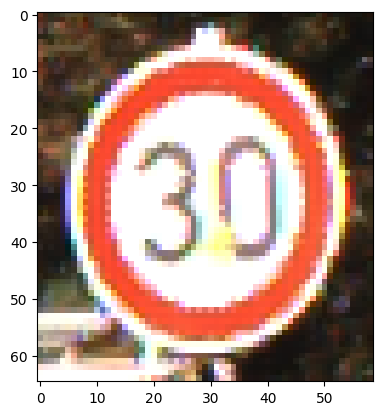

In [230]:
img = Image.open('data/gtsrb/test_A/00001/s00024.png')
class_id = 1

plt.imshow(img)



### Feed the image in all models 

Checking that the image is correctly classified by all models to allow for transferability evaluation

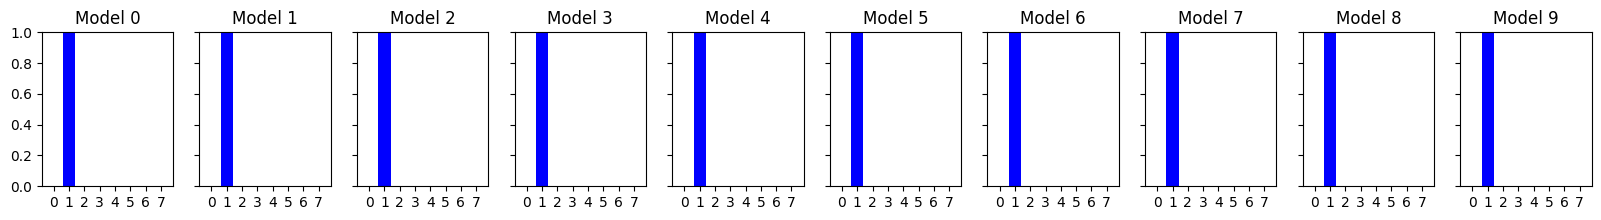

In [231]:
img_tensor = transform(img).unsqueeze(0).to(device)
plot_predictions(img_tensor, models, class_id)

## FGSM

Introduce in 2014, Fast Gradient Sign Method (FGSM), showed that the model's training algorithm, Backpropagation, could be used to create adversarial images. In regular training, we compute the gradients of the loss function with respect to the weights, and update the weights accordingly. IN contrast, FGSM computes the gradients with respect to the input image itself. The gradient can then be used to update the input image. 

FGSM generates perturbations in a single step. Let $\theta$ represent the model parameters, $x$ the input image, $y$ its true class, and $L(\theta, x, y)$ the loss function. Then the perturbation is:

$\eta = \epsilon \times sign(\nabla_x(L(\theta, x, y)))$

The adversarial image can be computed as:

$z = x + \eta $

The gradient is computed with respect to the image, the gradient sign is taken and is multiplied by a small constant $\epsilon$. This perturbation $\eta$ in then summed to the original image. If the resulting image is misclassified by the model then it is called an adversarial sample.


### Feed the image in the first model and compute the gradients relatively to the input

In [232]:
loss_fn = torch.nn.CrossEntropyLoss()

def compute_FGSM_perturbation(image, label, model, epsilon):

    image.requires_grad = True
    output = model(image)
    loss = loss_fn(output, label)
    model.zero_grad()
    loss.backward()
    perturbation = epsilon * image.grad.data.sign()

    return perturbation


In [233]:
epsilon = 0.05

perturbation = compute_FGSM_perturbation(img_tensor, torch.tensor([1]).to(device), models[0], epsilon )

adversarial = img_tensor + perturbation

### Check if the adversarial is misclassified

In [234]:
output = models[0](adversarial)
out_probs = torch.nn.functional.softmax(output[0], -1)
print(out_probs.cpu().detach().numpy(), np.argmax(out_probs.cpu().detach().numpy()))

[1.2276101e-09 2.6527548e-06 1.4539404e-06 2.8907377e-07 3.1202493e-10
 9.9999571e-01 8.5595137e-10 4.1612136e-09] 5


### Show the images

Original image , perturbation, adversarial image

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


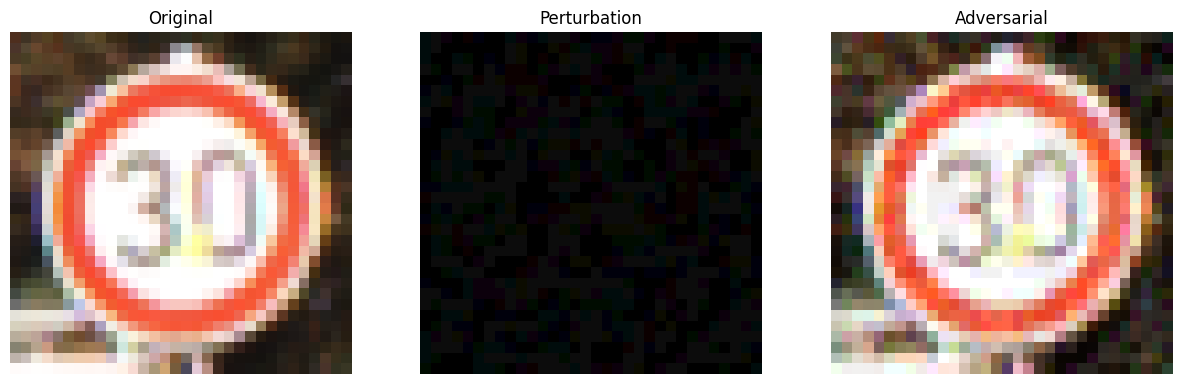

In [235]:
plot_adversarial(img_tensor, perturbation, adversarial)

### Plot predictions on all models to evaluate transferability

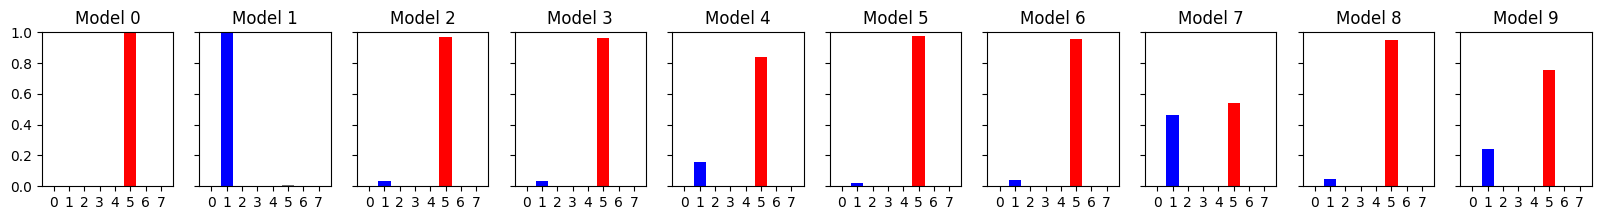

In [236]:
plot_predictions(adversarial, models, class_id)

Note that the adversarial may be invalid as an image, as it may contain values that are outside of the range 0...1

Hence, it is important to consider the clamped version.

In [237]:

adversarial_clamped = adversarial.clamp(0,1)

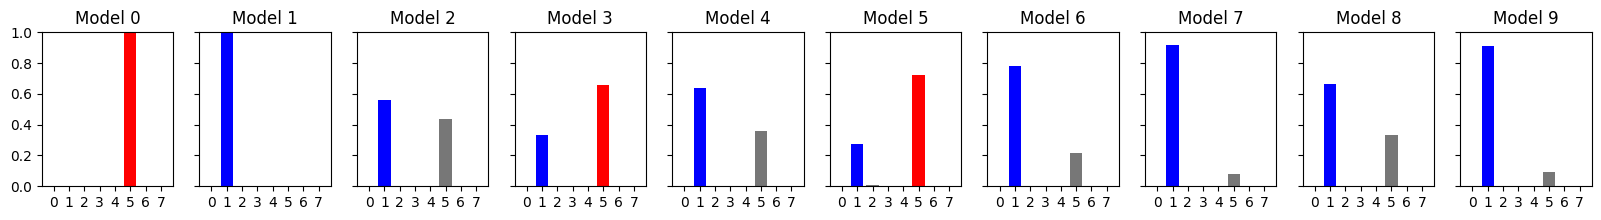

In [238]:
plot_predictions(adversarial_clamped, models, class_id)

Printing the classes predicted by each model

In [239]:
for i in range(0,10):

    output = models[i](adversarial)
    out_probs = torch.nn.functional.softmax(output[0], -1)
    print(np.argmax(out_probs.cpu().detach().numpy()))

5
1
5
5
5
5
5
5
5
5


## Targeted attack

The original FGSM was designed to craft adversarial samples by creating perturbations that cause images to be misclassified, without control over which incorrect class the model predicts. This is known as a **non-targeted attack**.

However, the same approach can be easily adapted to create adversarial samples that are not just misclassified, but get classified in a specific (incorrect) class chosen by the attacker. This variant is known as **targeted attacks**.

To perform a targeted attack on an original image $x$, the attacker picks a class, and the loss function is computed as if that class was correct. The perturbation $\eta$ is then computed, and the adversarial image $Z$  is obtained by  **adding** the perturbation to the original image:

$z = x - \eta $

In [240]:
#note: epsilon has to be set higher than in the non-targeted attack
epsilon = 0.15

perturbation = compute_FGSM_perturbation(img_tensor, torch.tensor([6]).to(device), models[0], epsilon )

adversarial = (img_tensor - perturbation).clamp(0,1)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


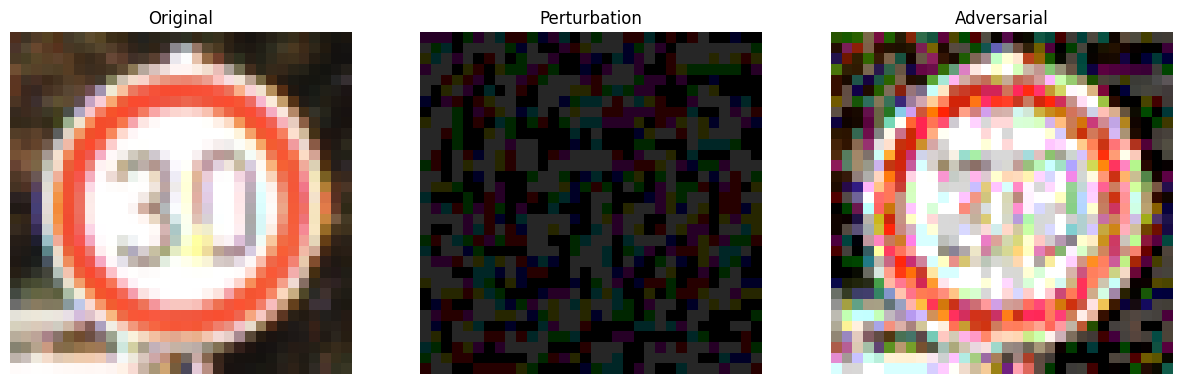

In [241]:
plot_adversarial(img_tensor, perturbation, adversarial)

Checking if the adversarial was successfully crafted

In [242]:
output = models[0](adversarial).cpu().detach().numpy()
print(output, np.argmax(output))

[[-12.215089   -8.776118  -11.755227  -16.154028   -7.854657   -7.28629
    6.4265585  -2.9998841]] 6


Checking transferability

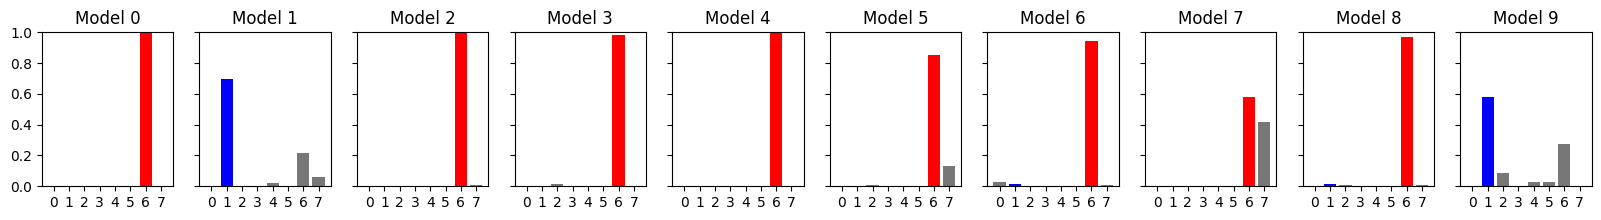

In [243]:
plot_predictions(adversarial.clamp(0,1), models, 1)

The effect of $\epsilon$ in the image perturbation

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


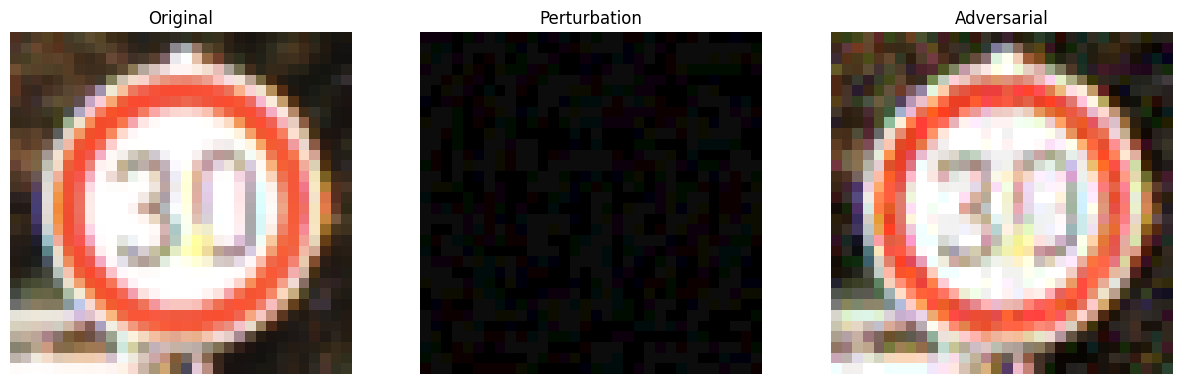

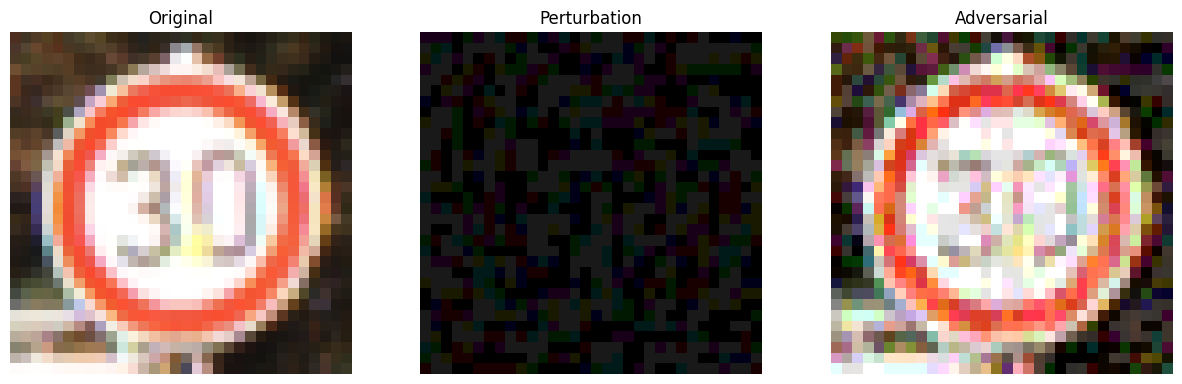

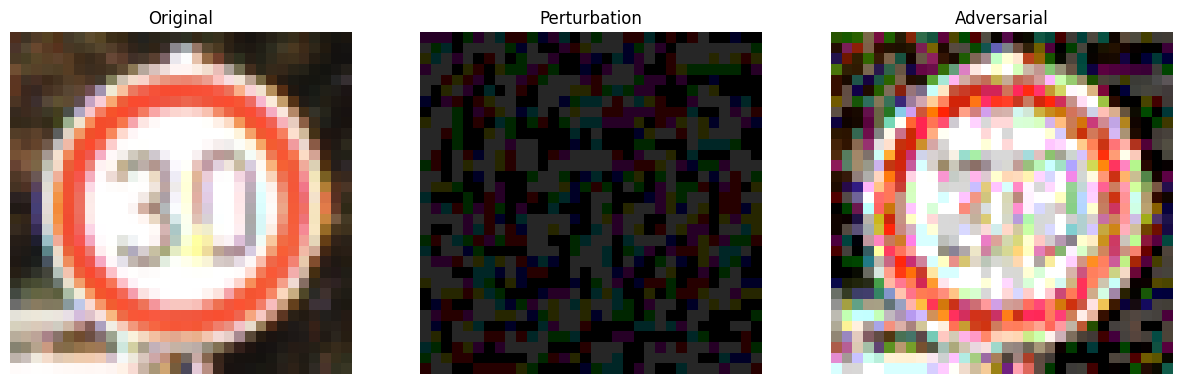

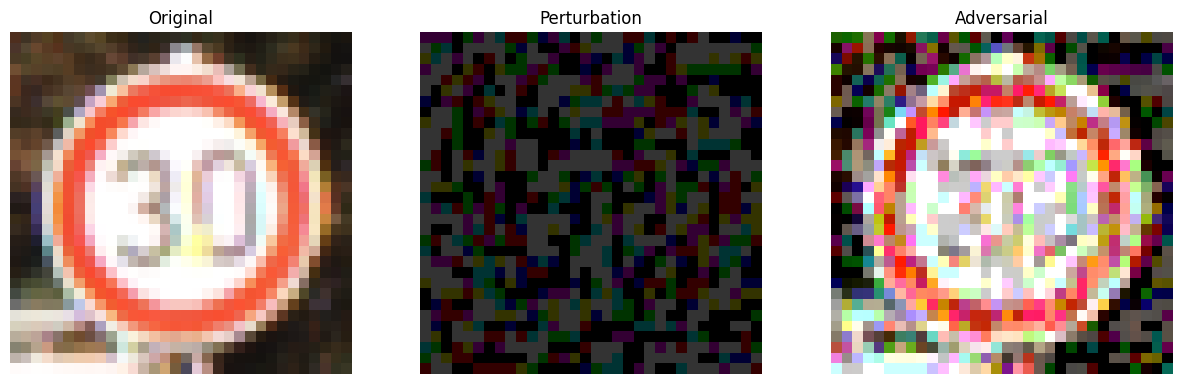

In [244]:
epsilon = 0.05
perturbation = compute_FGSM_perturbation(img_tensor, torch.tensor([6]).to(device), models[0], epsilon )
adversarial = (img_tensor - perturbation).clamp(0,1)
plot_adversarial(img_tensor, perturbation, adversarial)

epsilon = 0.10
perturbation = compute_FGSM_perturbation(img_tensor, torch.tensor([6]).to(device), models[0], epsilon )
adversarial = (img_tensor - perturbation).clamp(0,1)
plot_adversarial(img_tensor, perturbation, adversarial)

epsilon = 0.15
perturbation = compute_FGSM_perturbation(img_tensor, torch.tensor([6]).to(device), models[0], epsilon )
adversarial = (img_tensor - perturbation).clamp(0,1)
plot_adversarial(img_tensor, perturbation, adversarial)

epsilon = 0.20
perturbation = compute_FGSM_perturbation(img_tensor, torch.tensor([6]).to(device), models[0], epsilon )
adversarial = (img_tensor - perturbation).clamp(0,1)
plot_adversarial(img_tensor, perturbation, adversarial)

## Iterative FGSM

In [245]:
def compute_I_FGSM_adversarial(image, label, targeted, model, iterations, epsilon, alpha):

    original_image = image.detach()
    adversarial = original_image.clone().detach()

    for i in range(iterations):

        adversarial.requires_grad = True
        output = model(adversarial)
        loss = loss_fn(output, label)
        loss.backward()

        # compute perturbation
        perturbation = alpha * adversarial.grad.data.sign()
        
        # update adversarial
        if targeted:
            adversarial = adversarial - perturbation
        else:
            adversarial = adversarial + perturbation

        # clamp update relative to the original image
        delta = torch.clamp(adversarial - original_image, -epsilon, +epsilon)
        adversarial = torch.clamp(original_image + delta, min=0, max=1).detach()

    return adversarial, delta
    

In [246]:
epsilon = 0.15
alpha = 0.10
adversarial, perturbation = compute_I_FGSM_adversarial(img_tensor, torch.tensor([6]).to(device), True, models[0], 20, epsilon, 0.05)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


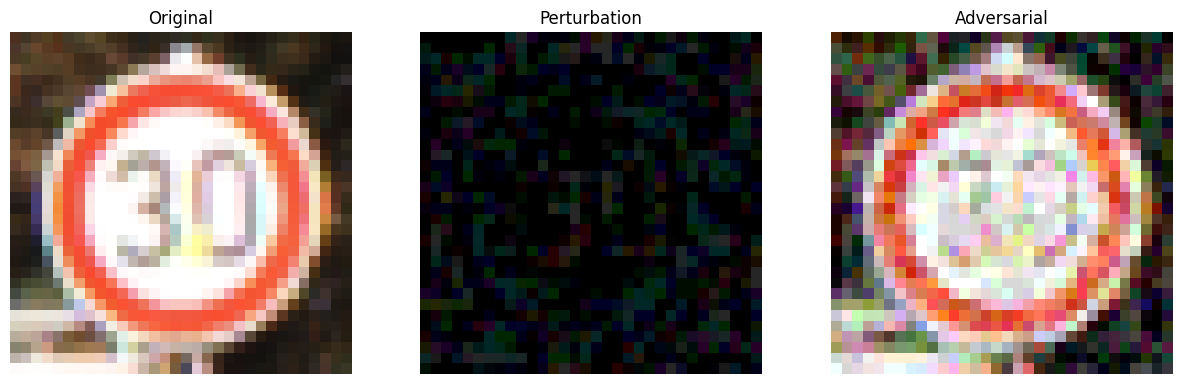

In [247]:
plot_adversarial(img_tensor, perturbation, adversarial)

Check transferability

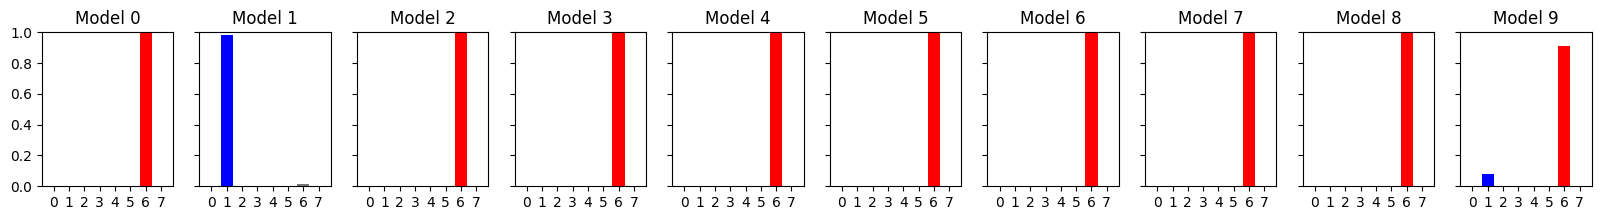

In [248]:
plot_predictions(adversarial, models, 1)

## Projected Gradient Descent (PGD) $L_{\infty}$ version

PGD extends I-FGSM by allowing for different norms, such as $L_1$ and $L_2$.

Furthermore, the PGD paper proposes:

- Starting from a random point within the $\epsilon$-ball around the original input
- Performing multiple restarts to generate multiple adversarial examples and increase the likelihood of a successful attack

Below is an implementation of PGD $L_{\infty}$ with random starts. Multiple restarts can be implemented calling the function multiple times.

In [249]:
def compute_PGD_Linf_adversarial(image, label, targeted, model, iterations, epsilon, alpha):

    original_image = image.detach()
    adversarial = original_image.clone().detach()

    # random start
    adversarial = adversarial + torch.empty_like(adversarial).uniform_(-epsilon, epsilon)
    adversarial = torch.clamp(adversarial, min=0, max=1)

    # similar to I-FGSM
    for i in range(iterations):

        adversarial.requires_grad = True
        output = model(adversarial)
        loss = loss_fn(output, label)
        loss.backward()

        # compute perturbation
        perturbation = alpha * adversarial.grad.data.sign()
        
        # update adversarial
        if targeted:
            adversarial = adversarial - perturbation
        else:
            adversarial = adversarial + perturbation

        # clamp update relative to the original image
        delta = torch.clamp(adversarial - original_image, -epsilon, +epsilon)
        adversarial = torch.clamp(original_image + delta, min=0, max=1).detach()

    return adversarial, delta

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


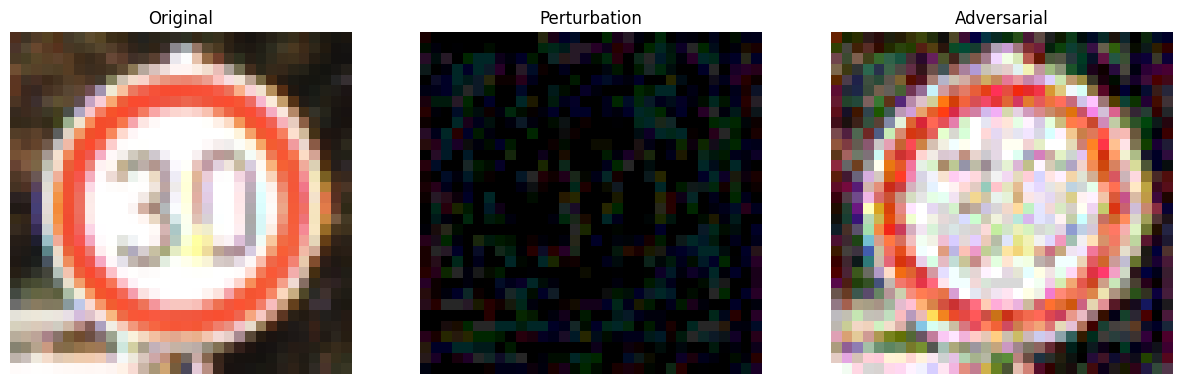

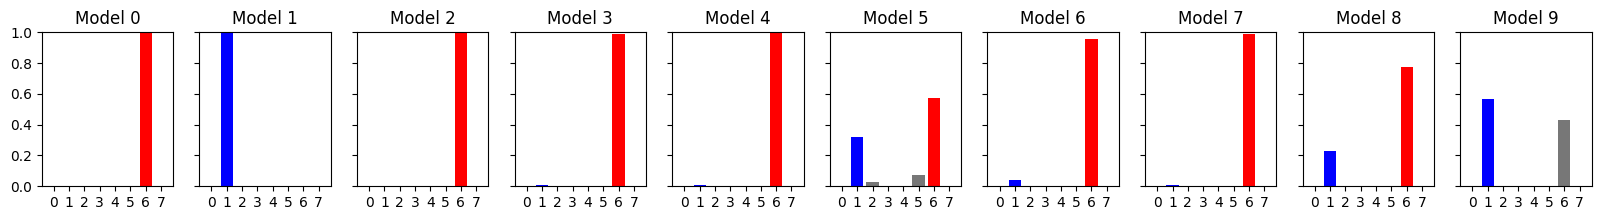

In [250]:
epsilon = 0.15
alpha = epsilon/10
adversarial, perturbation = compute_PGD_Linf_adversarial(img_tensor, torch.tensor([6]).to(device), True, models[0], 200, epsilon, 0.05)

plot_adversarial(img_tensor, perturbation, adversarial)

plot_predictions(adversarial, models, 1)

When using multiple restarts, multiple adversarial samples are obtained. Which one should we pick?

Selecting the adversarial sample that performs best on the surrogate model (i.e., highest misclassification loss for non-targeted attacks, or lowest classification error for targeted attacks) is standard practice, as it maximizes attack strength on that model. However, this approach can lead to overfitting to the surrogate, potentially reducing transferability to other models.

This overfitting risk arises because the selected adversarial may exploit model-specific weaknesses that do not generalize. As a result, recent research explores strategies such as increasing output diversity, using ensembles, or aggregating adversarial examples (e.g., adversarial soups) to improve transferability rather than relying solely on the single "best" adversarial 

Refs addressing the overfitting risk and proposing solutions:

- Rice, L., Wong, E., & Kolter, J. Z. (2020). Overfitting in adversarially robust deep learning - https://proceedings.mlr.press/v119/rice20a/rice20a.pdf

- Qin, C., Wang, Y., & Xu, K. (2021). Multi-stage Optimization based Adversarial Training - https://www.jmlr.org/papers/volume25/22-0950/22-0950.pdf

- Qin, C., Wang, Y., & Xu, K. (2021). Multi-stage Optimization based Adversarial Training - https://arxiv.org/pdf/2106.15357




### PGD $L_2$ 

In [251]:
def L2_proj(delta, epsilon):
    # Project delta onto the L2 ball of radius epsilon (for a single image)
    flat = delta.reshape(-1)
    norm = torch.norm(flat, p=2)
    if norm > epsilon:
        flat = flat * (epsilon / norm)
    return flat.view_as(delta)

In [252]:
def compute_PGD_L2_adversarial(image, label, targeted, model, iterations, epsilon, alpha):

    original_image = image.detach()

    # random start
    delta = torch.randn_like(image)
    norm = torch.norm(delta.reshape(delta.size(0), -1), p=2, dim=1, keepdim=True)
    r = torch.rand(delta.size(0), 1, 1, 1, device=device)  # shape (1, 1, 1, 1)
    delta = delta / (norm.view(-1, 1, 1, 1) + 1e-12) * r * epsilon
    adversarial = torch.clamp(original_image + delta, min=0, max=1).detach()


    # similar to I-FGSM
    for i in range(iterations):

        adversarial.requires_grad = True
        output = model(adversarial)
        loss = loss_fn(output, label)
        loss.backward()

        # compute perturbation
        grad = adversarial.grad
        grad_norm = torch.norm(grad.reshape(-1), p = 2)
        grad_normalized = grad / (grad_norm + 1e-12)
        perturbation = alpha * grad_normalized
        
        # update adversarial
        if targeted:
            adversarial = adversarial - perturbation
        else:
            adversarial = adversarial + perturbation

        # Project the delta relative to the original image
        delta = adversarial - original_image
        delta = L2_proj(delta, epsilon)
        adversarial = torch.clamp(original_image + delta, min=0, max=1).detach()

    return adversarial, delta

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


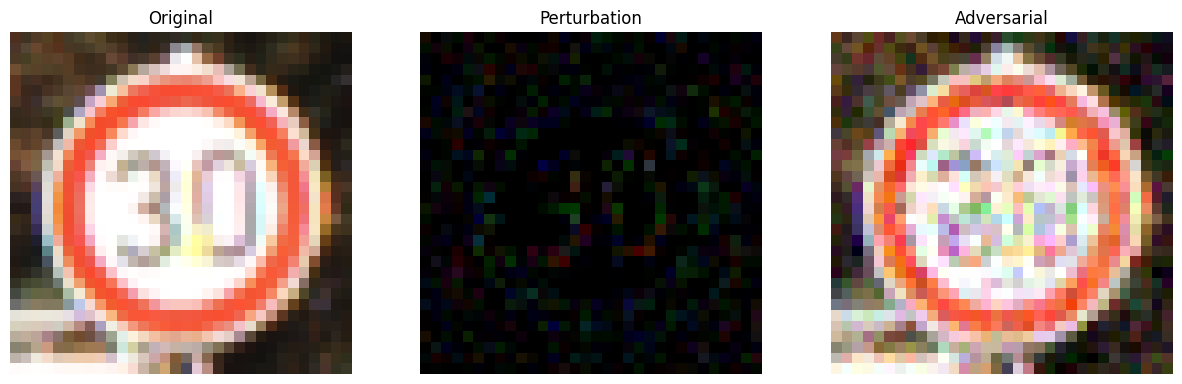

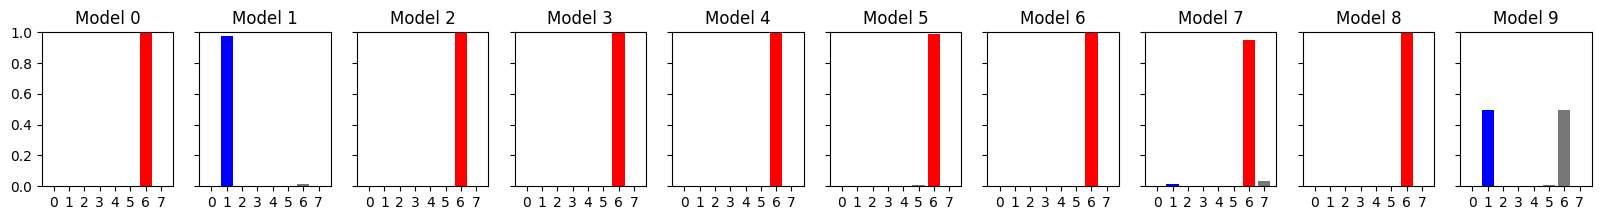

In [255]:
#converting from epsilon used in the L_inf version to the equivalent epsilon in L_2
epsilon_Linf = 0.15
epsilon = epsilon_Linf * np.sqrt(3 * 32 * 32)
alpha = epsilon/10

adversarial, perturbation = compute_PGD_L2_adversarial(img_tensor, torch.tensor([6]).to(device), True, models[0], 200, epsilon, 0.05)

plot_adversarial(img_tensor, perturbation, adversarial)

plot_predictions(adversarial, models, 1)